In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
using JJDFTX
using PyPlot

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [2]:
force_matrix, cell_map = phonon_force_matrix("Na-0.289");

Number of phonon modes is: 159
If this is incorrect, something went wrong somewhere at some point.


In [4]:
phonon_dispersion(force_matrix, cell_map, [0, 0, 0], return_negative=true);

In [7]:
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="../../bandstruct.kpoints", return_negative=true);


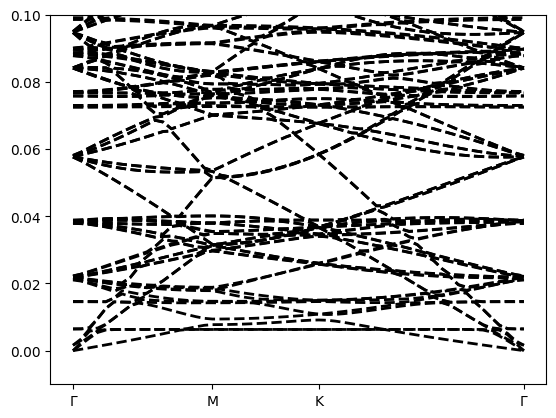

(-0.01, 0.1)

In [20]:
plot(phonon_bands, linewidth=2, color="black", linestyle="dashed")
label_plots()
ylim(-0.01, 0.1)

In [24]:
kpts = bandstructkpoints2q(filename = "./bandstruct.kpoints");

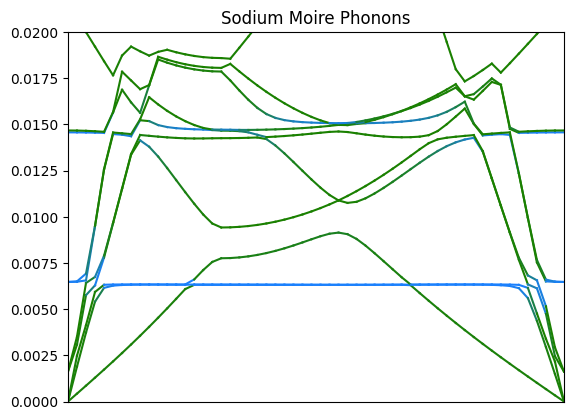

PyObject Text(0.5, 1.0, 'Sodium Moire Phonons')

In [35]:
for i in 1:10
    for j in 1:55
        y1= phonon_bands[j, i]
        y2 = phonon_bands[j+1, i]
        kpt = kpts[j]
        Na_Overlap = sum((abs.(phonon_dispersionmodes(force_matrix, cell_map, kpt)[2][1:3, i])).^2)
        plot([j, j+1], [y1, y2], color=[0.1, 0.5, Na_Overlap]) #linewidth=(3+Na_Overlap*4),)
    end
end
xticks(Float64[])
ylim(0, 0.02)
xlim(1, 56)
title("Sodium Moire Phonons")

In [31]:
phonon_dispersionmodes(force_matrix, cell_map, [0, 0, 0])[2][151:153, 2]

3-element Vector{ComplexF64}:
    0.12719297265187135 + 0.0im
 -1.9217777516719603e-5 + 0.0im
 -1.5342029246294409e-6 + 0.0im